In [18]:
import pymc as pm, polars as pl, arviz as az, numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import legend

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [19]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/bangladesh.csv", separator=";").drop("age.centered", "living.children").with_columns(
    district=pl.when(pl.col("district") < 54).then("district").otherwise(pl.col("district")-1)-1
)

In [28]:
with pm.Model(coords={
        "district": df["district"].unique().sort(),
    }) as model:
    # define data
    district = pm.Data("district", df["district"].to_numpy())
    urban = pm.Data("urban", df["urban"].to_numpy())

    # prior on log-odds scale
    alpha = pm.Normal("a_district", 0, 2, dims="district")


    probs = pm.Deterministic("probs", pm.invlogit(alpha[district]))
    uses_contraception = pm.Bernoulli("uses_contraception", probs, observed=df["use.contraception"].to_numpy())

    # sample posterior
    posterior = pm.sample(chains=4, draws=1000)
    posterior_predictive = pm.sample_posterior_predictive(posterior)
    pm.compute_log_likelihood(posterior)

with pm.Model(coords={
        "district": df["district"].unique().sort(),
    }) as multilevel_model:
    # define data
    district = pm.Data("district", df["district"].to_numpy())
    urban = pm.Data("urban", df["urban"].to_numpy())

    # prior on log-odds scale
    alpha_bar = pm.Normal("alpha_bar", 0, 1)
    alpha = pm.Normal("a_district", alpha_bar, 0.5, dims="district")


    probs = pm.Deterministic("probs", pm.invlogit(alpha[district]))
    uses_contraception = pm.Bernoulli("uses_contraception", probs, observed=df["use.contraception"].to_numpy())

    # sample posterior
    posterior_multilevel = pm.sample(chains=4, draws=1000)
    posterior_predictive_multilevel = pm.sample_posterior_predictive(posterior_multilevel)
    pm.compute_log_likelihood(posterior_multilevel)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a_district]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Sampling: [a_district, uses_contraception]


Output()

Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_bar, a_district]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Sampling: [a_district, uses_contraception]


Output()

Output()

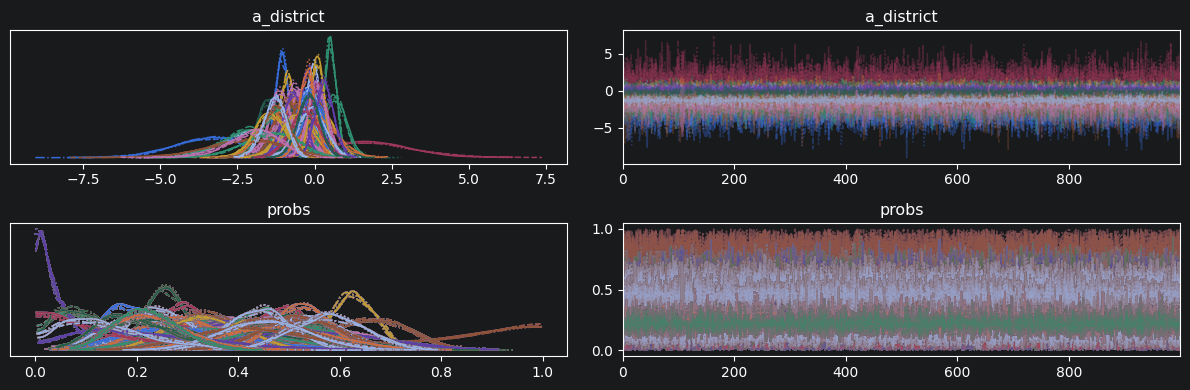

In [22]:
plot_trace(posterior, var_names=["a_district", "probs"])

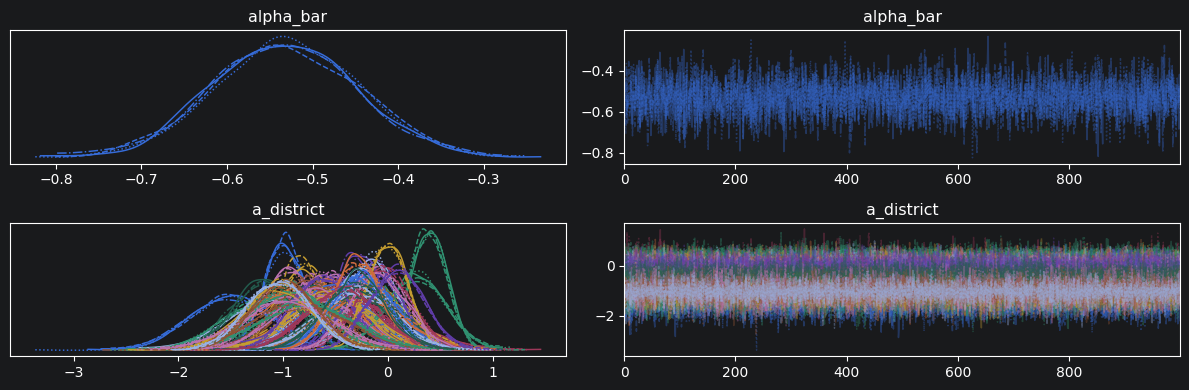

In [27]:
plot_trace(posterior_multilevel, var_names=["alpha_bar", "a_district"])

In [25]:
comparison = az.compare({
    "basic": posterior,
    "multilevel": posterior_multilevel
}, scale="deviance")
comparison

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
multilevel,0,2513.691797,34.712248,0.00000,0.867586,24.875014,0.000000,False,deviance
basic,1,2528.686027,57.944575,14.99423,0.132414,30.220003,9.305288,False,deviance


<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_loo (deviance)', ylabel='ranked models'>

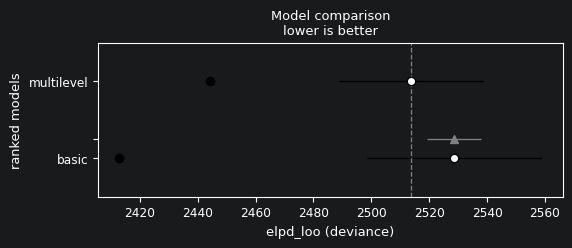

In [26]:
az.plot_compare(comparison, plot_ic_diff=True, insample_dev=True)

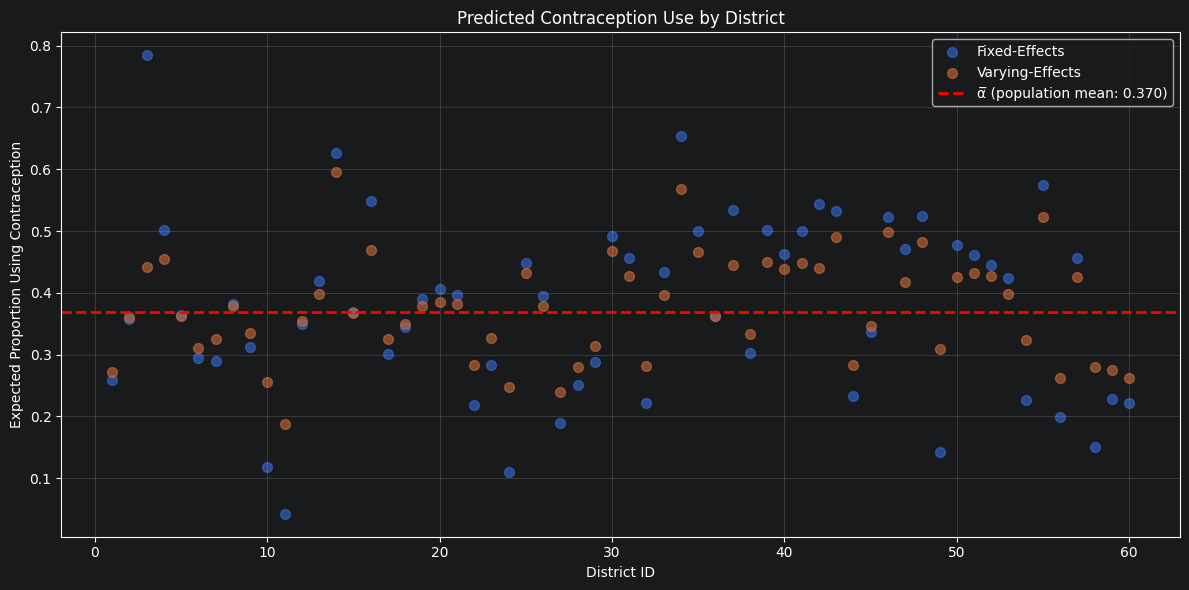

In [35]:
# Calculate mean predicted proportions by district for both models
districts = df["district"].to_numpy()
n_districts = len(df["district"].unique())

# Fixed-effects model
probs_fixed = posterior.posterior["probs"].mean(dim=["chain", "draw"]).values
district_probs_fixed = np.array([probs_fixed[districts == d].mean() for d in range(n_districts)])

# Varying-effects model
probs_varying = posterior_multilevel.posterior["probs"].mean(dim=["chain", "draw"]).values
district_probs_varying = np.array([probs_varying[districts == d].mean() for d in range(n_districts)])

# Get alpha_bar (population mean on log-odds scale) and convert to probability scale
alpha_bar_mean = posterior_multilevel.posterior["alpha_bar"].mean().values
alpha_bar_prob = 1 / (1 + np.exp(-alpha_bar_mean))  # invlogit

# Create single plot with both models
plt.figure(figsize=(12, 6))
plt.scatter(range(1, n_districts + 1), district_probs_fixed, alpha=0.6, label="Fixed-Effects", s=50)
plt.scatter(range(1, n_districts + 1), district_probs_varying, alpha=0.6, label="Varying-Effects", s=50)
plt.axhline(alpha_bar_prob, color='red', linestyle='--', linewidth=2, label=f"α̅ (population mean: {alpha_bar_prob:.3f})")
plt.xlabel("District ID")
plt.ylabel("Expected Proportion Using Contraception")
plt.title("Predicted Contraception Use by District")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
df_districts = pl.DataFrame({
    "district": list(range(n_districts)),
    "fixed_effects_mean": district_probs_fixed,
    "varying_effects_mean": district_probs_varying
}).with_columns(abs_diff = (pl.col("fixed_effects_mean") - pl.col("varying_effects_mean")).abs())

In [45]:
df_districts

district,fixed_effects_mean,varying_effects_mean,abs_diff
i64,f64,f64,f64
0,0.258697,0.271796,0.013099
1,0.357539,0.361239,0.003699
2,0.784421,0.44254,0.341881
3,0.501428,0.454639,0.046789
4,0.363639,0.363145,0.000494
…,…,…,…
55,0.198808,0.26203,0.063222
56,0.4563,0.426297,0.030003
57,0.150031,0.279536,0.129505


In [43]:
df.group_by("district").len()

district,len
i64,u32
3,30
58,32
39,41
10,21
48,4
…,…
52,19
54,45
0,117
